In [1]:
import pandas as pd

In [2]:
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/Volumes/LaCie/data/spotify_user_behavior_realistic_50000_rows 2.csv')

In [4]:
df.head()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [5]:
df.columns

Index(['user_id', 'country', 'age', 'signup_date', 'subscription_type',
       'subscription_status', 'months_inactive', 'inactive_3_months_flag',
       'ad_interaction', 'ad_conversion_to_subscription',
       'music_suggestion_rating_1_to_5', 'avg_listening_hours_per_week',
       'favorite_genre', 'most_liked_feature', 'desired_future_feature',
       'primary_device', 'playlists_created', 'avg_skips_per_day'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  object 
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  object 
 4   subscription_type               50000 non-null  object 
 5   subscription_status             50000 non-null  object 
 6   months_inactive                 50000 non-null  int64  
 7   inactive_3_months_flag          50000 non-null  int64  
 8   ad_interaction                  50000 non-null  object 
 9   ad_conversion_to_subscription   50000 non-null  object 
 10  music_suggestion_rating_1_to_5  50000 non-null  int64  
 11  avg_listening_hours_per_week    50000 non-null  float64
 12  favorite_genre                  

In [7]:
#data looks clean


In [8]:
df.shape

(50000, 18)

In [9]:
df['signup_date'] = pd.to_datetime(df['signup_date'])

In [10]:
df['signup_date'].dtype

dtype('<M8[ns]')

In [11]:
df['subscription_status'].value_counts()

Active      42109
Inactive     7891
Name: subscription_status, dtype: int64

In [12]:
df.groupby('subscription_status')['avg_listening_hours_per_week'].mean()

subscription_status
Active      9.987028
Inactive    9.999435
Name: avg_listening_hours_per_week, dtype: float64

In [13]:
df.groupby('subscription_status')['subscription_type'].value_counts()

subscription_status  subscription_type 
Active               Free                  19012
                     Premium Individual    11829
                     Student                3772
                     Premium Family         3768
                     Premium Duo            3728
Inactive             Free                   3513
                     Premium Individual     2200
                     Student                 744
                     Premium Duo             720
                     Premium Family          714
Name: subscription_type, dtype: int64

In [14]:
df.groupby('subscription_type')['subscription_status'].value_counts(normalize=True).unstack()

subscription_status,Active,Inactive
subscription_type,,
Free,0.844040,0.155960
Premium Duo,0.838129,0.161871
Premium Family,0.840696,0.159304
Premium Individual,0.843182,0.156818
Student,0.835252,0.164748


In [15]:
df.groupby('subscription_status')['age'].mean()

subscription_status
Active      38.005058
Inactive    38.038145
Name: age, dtype: float64

In [16]:
df.groupby('subscription_status')['avg_skips_per_day'].mean()

subscription_status
Active      10.022038
Inactive    10.046635
Name: avg_skips_per_day, dtype: float64

In [17]:
# tough to find any core reason as to why people are inactive from this data


<AxesSubplot:>

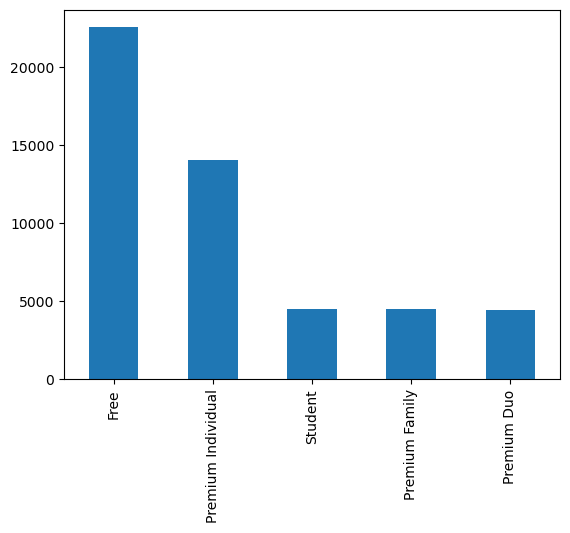

In [18]:
df['subscription_type'].value_counts().plot(kind = 'bar')

In [19]:
df.groupby('country')['subscription_type'].value_counts()

country    subscription_type 
Australia  Free                  1878
           Premium Individual    1155
           Student                382
           Premium Family         374
           Premium Duo            325
Brazil     Free                  1899
           Premium Individual    1171
           Student                405
           Premium Family         374
           Premium Duo            366
Canada     Free                  1879
           Premium Individual    1221
           Student                383
           Premium Duo            371
           Premium Family         349
France     Free                  1920
           Premium Individual    1133
           Student                375
           Premium Duo            357
           Premium Family         352
Germany    Free                  1820
           Premium Individual    1203
           Premium Family         390
           Student                380
           Premium Duo            367
India      Free     

In [20]:
df.country

0           France
1        Indonesia
2            Italy
3            Italy
4        Australia
           ...    
49995        India
49996        Italy
49997       Brazil
49998          USA
49999    Indonesia
Name: country, Length: 50000, dtype: object

In [21]:
df['country'].unique()

array(['France', 'Indonesia', 'Italy', 'Australia', 'India', 'Germany',
       'UK', 'Brazil', 'Canada', 'Mexico', 'USA', 'Spain'], dtype=object)

<AxesSubplot:>

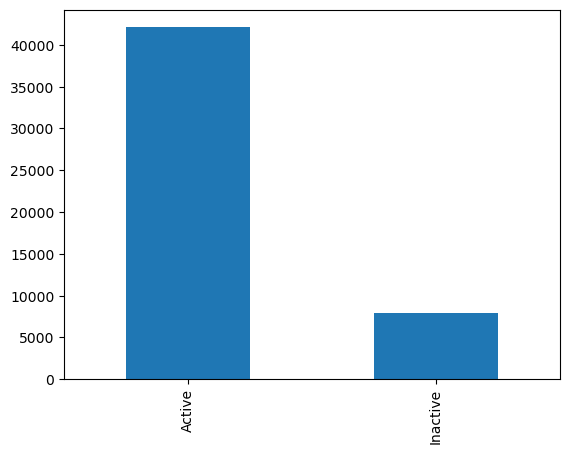

In [22]:
df['subscription_status'].value_counts().plot(kind = 'bar')

In [24]:
df.groupby('primary_device')['avg_listening_hours_per_week'].mean()

primary_device
Car System        9.977037
Desktop          10.047064
Mobile            9.996613
Smart Speaker     9.917875
Tablet           10.006703
Name: avg_listening_hours_per_week, dtype: float64